In [1]:
%load_ext autoreload
%autoreload 2
import sys
import numpy as np
sys.path.append('..') # add parent directory

from scaling.util import (
    download_data,
    plot_validation_accuracy,
    plot_total_parameters,
    plot_train_times,
    plot_flops,
)

entity = "ga92xug"
project = "scaling-laws-eq"

In [9]:
run_dict = {
    "depth": {
        "run_ids": ["i1xirj9q", "zej6qb0b", "to2jjlyp"],
        "long_labels": ["depth=16", "depth=22", "depth=28"],
        "short_labels": ["d=16", "d=22", "d=28"],
        "title": "Validation Acc Eq-WRN-X-2 varying depth"
    },
    "width": {
        "run_ids": ["vk37jyq8", "nl4adi0o", "x5ajaryv"],
        "long_labels": ["width=1", "width=2", "width=4"],
        "short_labels": ["w=1", "w=2", "w=4"],
        "title": "Validation Acc Eq-WRN-34-X varying width",
        "GFLOPs": [43.086858824, 148.618137432, 611.961191606]
    },
    # G_CNN_exp3
    "rotation": {
        "run_ids": ["1b6hywk3", "ymdhnpug", "kl7sg4c3", "bv1hfyo4", ],
        "long_labels": ["C=2", "C=4", "C=8", "C=12"],
        "short_labels": ["C=2", "C=4", "C=8", "C=12"],
        "title": "Validation Acc Eq-WRN-16-4 varying rotation",
        "GFLOPs": [67.359442844, 119.576, 226.288036046, 313.57],
        # 16: 423.225014106
        # 20: 511.692473268
    },
    "rotation_5x5": {
        "short_labels": ["C=2", "C=4", "C=6", "C=8", "C=10", "C=12", "C=16", "C=20"],
        "GFLOPs": [184.507381912, 327.797367425, 466.53433024, 621.08362177, 734.797687934, 861.263894734, 1163.956753166, 1407.564055544],
    }
}

In [3]:
import os
from matplotlib import gridspec
import matplotlib.pyplot as plt
import pandas as pd

def smooth_data(data, window=5):
    df = pd.DataFrame(data)
    smoothed_data = df.rolling(window=window, axis=1, min_periods=1).mean().values
    return smoothed_data

def save_plot(figure, type_plot, experiment_type, folder_name='figures/first_experiments'):
    experiment_type = experiment_type.replace(' ', '_').lower()

    if not os.path.exists(f'{folder_name}'):
        os.makedirs(f'{folder_name}')

    figure.savefig(f'{folder_name}/{experiment_type}_{type_plot}.png', dpi=300, bbox_inches = "tight")

def plot_flops(ax, gflops, labels):
    colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]
    ax.bar(labels, gflops, color=colors)
    ax.set_ylabel('FLOPs')

def plot_validation_accuracy(ax, valid_accs, labels):
    valid_accs = smooth_data(valid_accs)
    for i, acc in enumerate(valid_accs):
        ax.plot(acc, label=labels[i], linewidth=3)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy')
    ax.set_ylim(0.6, 1.0)
    ax.legend()
    ax.grid(True)
    ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])

def create_combined_plot(gflops, flop_labels, valid_accs, acc_labels, title):
    fig = plt.figure(figsize=(8, 4))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])

    ax1 = plt.subplot(gs[0])
    plot_flops(ax1, gflops, flop_labels)

    ax2 = plt.subplot(gs[1])
    plot_validation_accuracy(ax2, valid_accs, acc_labels)

    #fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_plot(fig, "valid_acc_flops_combined", title)
    plt.show()

In [10]:
for param, run_info in run_dict.items():
    if param != "rotation":
        continue

    run_ids = run_info["run_ids"]
    long_labels = run_info["long_labels"]
    short_labels = run_info["short_labels"]
    title = run_info["title"]
    valid_accs, total_params, gflops = download_data(entity, project, run_ids)
    
    if len(gflops) < len(total_params):
        # some old runs don't have flops, manually add them
        gflops = run_info["GFLOPs"]

    flops = (np.array(gflops) * 1e9)

    # plot_validation_accuracy(valid_accs, long_labels, param)
    # plot_total_parameters(total_params, short_labels, param)
    # #plot_train_times(train_times, short_labels, title)
    # 
    # plot_flops(flops, short_labels, param)

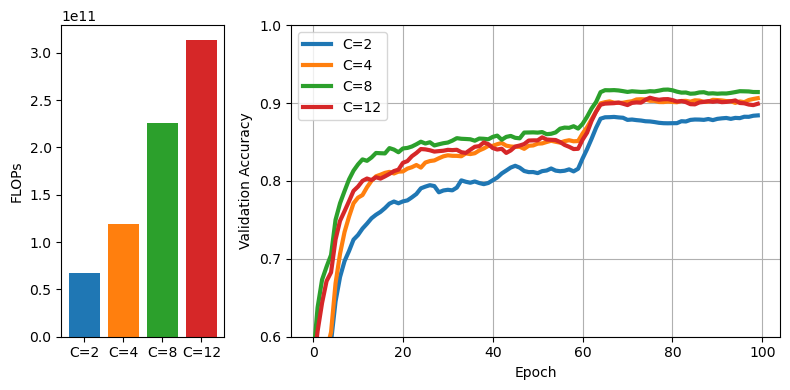

In [11]:
create_combined_plot(flops, short_labels, valid_accs, long_labels, param)

In [2]:
#run_ids = ["1b6hywk3", "hng9ovcr", "kl7sg4c3", "bv1hfyo4"] # G_CNN_exp3 rotation
run_ids = ["eb3ewgew", "mw0fndxz", "kl7sg4c3"] # G_CNN_exp4 restriction
# run_ids = ["v48n24cc", "kl7sg4c3"] # G_CNN_exp2 group
#run_ids = ["kl7sg4c3", "29e2c83c"] # Eq wrn vs wrn

entity = "ga92xug"
project = "scaling-laws-eq"

# Download the data
valid_accs, total_params, train_times = download_data(entity, project, run_ids)

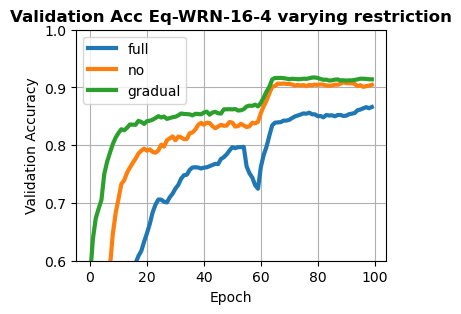

In [3]:
# Generate the plots
#labels = ["eq_wrn", "wrn"]
labels = ["full", "no", "gradual"]
#labels = ["dihedral", "cyclic"]
title = "Validation Acc Eq-WRN-16-4 varying restriction"
plot_validation_accuracy(valid_accs, labels, title)


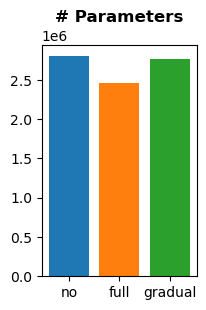

In [4]:
labels = ["no", "full", "gradual"]
plot_total_parameters(total_params, labels, title)

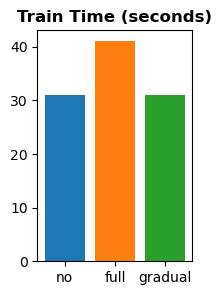

In [5]:
#plot_total_parameters(total_params, labels, title=None)
plot_train_times([31,41,31], labels, title)